# 점수를 활용해 regression 방식으로

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
sale = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\매물_피처병합_수정.csv', low_memory=False)


intersection = list(set(cafe) & set(sale))
# print( intersection )
inter_filtered = ['집객시설_수', '상권_코드', '지하철역_거리(m)', '버스_정거장_수', '교차로_존재_여부', '약국_수', 
 '초등학교_수', '백화점_수', 'est_총_유동인구_수', '지하철_역_수', '관공서_수', '일반_병원_수', 
 '숙박_시설_수', '종합병원_수', '중학교_수', '버스정류장_거리(m)', '슈퍼마켓_수', 
 '평일_대비_주말_유동인구_비율', '대학교_수', '은행_수', '고등학교_수', '반경500m내_카페수', 
 '접한길이_m', '도로2m이내접촉길이_m', '유치원_수', '극장_수']

In [10]:
# 점수에 주차와 층수 점수 확인
import pandas as pd
cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
score = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_성공여부.csv')
score.columns
score[['상가업소번호','parking_score','floor_score']].head(10)
score['총점_순수'] = score['총점'] - 0.2 * (score['parking_score']) - 0.2 * (score['floor_score'])
cafe = cafe.merge(score[['상가업소번호','총점_순수','parking_score', 'floor_score']], how = 'left', on = '상가업소번호')
print(cafe.isna().sum())

상가업소번호               0
상호명                  0
지점명              14446
상권_코드                0
상권_코드_명              0
                 ...  
지하철_역_수          11387
버스_정거장_수          1543
총점_순수             2851
parking_score     2851
floor_score       2851
Length: 69, dtype: int64


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1689
[LightGBM] [Info] Number of data points in the train set: 9119, number of used features: 9
[LightGBM] [Info] Start training from score 3.215366
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[54]	valid_0's l2: 0.626608
📉 Mean Squared Error: 0.6266
📈 R-squared: 0.0286


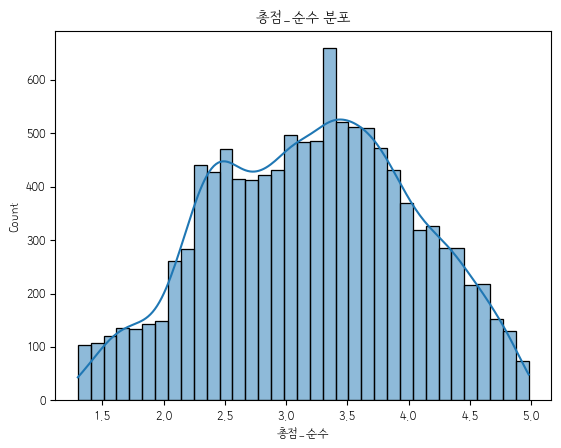

In [17]:
# 어떤 식으로 회귀를 짤 수 있을까?

# 필요한 라이브러리 가져오기

# 회귀
from lightgbm import LGBMRegressor, early_stopping
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
import pandas as pd
import numpy as np

########################################################################
# 학습세트 정리
# 우선 순수한 총점을 같이 가져옴 (추후에 추가할 예정)
cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
score = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_성공여부.csv')
score.columns
score[['상가업소번호','parking_score','floor_score']].head(10)
score['총점_순수'] = score['총점'] - 0.2 * (score['parking_score']) - 0.2 * (score['floor_score'])
cafe = cafe.merge(score[['상가업소번호','총점_순수']], how = 'left', on = '상가업소번호')

cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)
cafe_cleaned[['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수']] = cafe_cleaned[['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수']].fillna(0)
cafe_cleaned['교통시설_수'] = cafe_cleaned['버스_정거장_수'] + cafe_cleaned['지하철_역_수']
# 층수 처리
def convert_floor(floor):
    try:
        # B1, B2 등은 지하층을 의미하므로 음수로 변환
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1  # 오류가 나는 경우는 1층으로 처리
cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)


# 극단값 로그 변환
cafe_cleaned['도로2m이내접촉길이_log'] = np.log1p(cafe_cleaned['도로2m이내접촉길이_m'])
cafe_cleaned['est_총_유동인구_수_log'] =  np.log1p(cafe_cleaned['est_총_유동인구_수'])

train_cols = ['집객시설_수','지하철역_거리(m)','교차로_존재_여부', 'est_총_유동인구_수_log', '버스정류장_거리(m)', '평일_대비_주말_유동인구_비율', '반경500m내_카페수', '교통시설_수', '도로2m이내접촉길이_log']

X = cafe_cleaned[train_cols]
y = cafe_cleaned['총점_순수']


###############################################################
# 1. 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 모델 정의 및 학습
# LGBM
model = LGBMRegressor(
    objective='regression',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2',
    callbacks=[early_stopping(stopping_rounds=50)]
)

# 3. 예측
y_pred = model.predict(X_test)

# 4. 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📉 Mean Squared Error: {mse:.4f}")
print(f"📈 R-squared: {r2:.4f}")

sns.histplot(y, kde=True)
plt.title("총점_순수 분포")
plt.show()